# Clasificación Multiclase — PAMAP2: Monitoreo de Actividad Física

**Estudiante:** Isabel Romero Caspary

## Descripción del Dataset

El dataset **PAMAP2** (Physical Activity Monitoring) proviene del repositorio UCI Machine Learning Repository y contiene datos de sensores inerciales y cardíacos recogidos de 9 sujetos realizando 18 actividades físicas diferentes (caminar, correr, ciclismo, subir escaleras, etc.).

- **Número de ejemplos:** m ≥ 50.000 registros
- **Número de propiedades:** n ≥ 40 características por muestra (acelerómetros, giroscopios, magnetómetros en muñeca, pecho y tobillo)
- **Clases:** actividades físicas etiquetadas numéricamente
- **Tipo:** Dataset no gráfico (series temporales de sensores)

El objetivo es entrenar un modelo de **regresión logística one-vs-all** para clasificar la actividad física a partir de las lecturas de sensores.

## 1. Montaje de Google Drive y carga de librerías

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# Manipulación de directorios y rutas
import os

# Cálculo científico y vectorial
import numpy as np

# Preprocesamiento con Pandas
import pandas as pd

# Librería para gráficos
from matplotlib import pyplot
import matplotlib.pyplot as plt

# Módulo de optimización
from scipy import optimize

# Gráficos en el cuaderno
%matplotlib inline

## 2. Carga y Preprocesamiento del Dataset con Pandas

El dataset PAMAP2 se distribuye en múltiples archivos `.dat` (uno por sujeto). Cada archivo contiene columnas de: timestamp, activityID, frecuencia cardíaca, y lecturas de tres IMUs (muñeca, pecho, tobillo) con acelerómetro 16g, acelerómetro 6g, giroscopio y magnetómetro (cada uno con 3 ejes), además de temperatura.

Se utiliza **Pandas** para:
- Leer y concatenar todos los archivos de los sujetos
- Eliminar columnas con varianza cero o casi nula (acelerómetro 6g duplicado)
- Remover filas con valores NaN
- Balancear las clases (misma cantidad de ejemplos por actividad)
- Separar características (X) y etiquetas (y)

In [7]:
# Columnas del dataset PAMAP2 según documentación oficial
columnas = [
    'timestamp', 'activityID', 'heart_rate',
    # IMU mano
    'hand_temp',
    'hand_acc16_x', 'hand_acc16_y', 'hand_acc16_z',
    'hand_acc6_x',  'hand_acc6_y',  'hand_acc6_z',
    'hand_gyro_x',  'hand_gyro_y',  'hand_gyro_z',
    'hand_mag_x',   'hand_mag_y',   'hand_mag_z',
    'hand_or_1',    'hand_or_2',    'hand_or_3',    'hand_or_4',
    # IMU pecho
    'chest_temp',
    'chest_acc16_x','chest_acc16_y','chest_acc16_z',
    'chest_acc6_x', 'chest_acc6_y', 'chest_acc6_z',
    'chest_gyro_x', 'chest_gyro_y', 'chest_gyro_z',
    'chest_mag_x',  'chest_mag_y',  'chest_mag_z',
    'chest_or_1',   'chest_or_2',   'chest_or_3',   'chest_or_4',
    # IMU tobillo
    'ankle_temp',
    'ankle_acc16_x','ankle_acc16_y','ankle_acc16_z',
    'ankle_acc6_x', 'ankle_acc6_y', 'ankle_acc6_z',
    'ankle_gyro_x', 'ankle_gyro_y', 'ankle_gyro_z',
    'ankle_mag_x',  'ankle_mag_y',  'ankle_mag_z',
    'ankle_or_1',   'ankle_or_2',   'ankle_or_3',   'ankle_or_4'
]

# Ruta base del dataset en Google Drive
ruta_base = '/content/drive/MyDrive/SIS420/Protocol/'

# Leer y concatenar todos los sujetos
lista_df = []
for i in range(1, 10):  # sujetos 101 a 109
    archivo = ruta_base + f'subject10{i}.dat'
    if os.path.exists(archivo):
        df_sujeto = pd.read_csv(archivo, sep=' ', header=None, names=columnas)
        lista_df.append(df_sujeto)

df = pd.concat(lista_df, ignore_index=True)
print(f'Dimensiones originales: {df.shape}')
print(f'Actividades únicas: {sorted(df["activityID"].unique())}')

Dimensiones originales: (2872533, 54)
Actividades únicas: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(12), np.int64(13), np.int64(16), np.int64(17), np.int64(24)]


In [8]:
# Eliminar actividad 0 (transición entre actividades)
df = df[df['activityID'] != 0]

# Eliminar columnas de orientación (cuaterniones, alta correlación y NaN frecuente)
cols_orientacion = [c for c in df.columns if 'or_' in c]
df = df.drop(columns=cols_orientacion)

# Eliminar timestamp (no es una característica)
df = df.drop(columns=['timestamp'])

# Eliminar filas con NaN
df = df.dropna()

print(f'Dimensiones después de limpieza: {df.shape}')
print(f'Actividades presentes: {sorted(df["activityID"].unique())}')
print(f'Distribución de clases:\n{df["activityID"].value_counts().sort_index()}')

Dimensiones después de limpieza: (175498, 41)
Actividades presentes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(12), np.int64(13), np.int64(16), np.int64(17), np.int64(24)]
Distribución de clases:
activityID
1     17575
2     16881
3     17256
4     20998
5      8665
6     14933
7     16857
12    10699
13     9585
16    15997
17    21696
24     4356
Name: count, dtype: int64


In [9]:
# Balanceo de clases: mínimo número de ejemplos entre todas las clases
min_ejemplos = df['activityID'].value_counts().min()
print(f'Mínimo de ejemplos por clase antes de balanceo: {min_ejemplos}')

# Aplicar submuestreo para equilibrar
df_balanceado = df.groupby('activityID').apply(
    lambda x: x.sample(n=min_ejemplos, random_state=42)
).reset_index(drop=True)

print(f'Dimensiones tras balanceo: {df_balanceado.shape}')
print(f'Distribución balanceada:\n{df_balanceado["activityID"].value_counts().sort_index()}')

Mínimo de ejemplos por clase antes de balanceo: 4356
Dimensiones tras balanceo: (52272, 41)
Distribución balanceada:
activityID
1     4356
2     4356
3     4356
4     4356
5     4356
6     4356
7     4356
12    4356
13    4356
16    4356
17    4356
24    4356
Name: count, dtype: int64


/tmp/ipykernel_2080/2841297010.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_balanceado = df.groupby('activityID').apply(


In [10]:
# Separar características y etiquetas
X = df_balanceado.drop(columns=['activityID']).values
y_raw = df_balanceado['activityID'].values

# Re-etiquetar clases a 0, 1, 2, ..., K-1
clases_unicas = sorted(np.unique(y_raw))
mapeo = {cls: idx for idx, cls in enumerate(clases_unicas)}
y = np.array([mapeo[val] for val in y_raw])

num_labels = len(clases_unicas)
m, n = X.shape

print(f'Número de ejemplos (m): {m}')
print(f'Número de propiedades (n): {n}')
print(f'Número de clases: {num_labels}')
print(f'Clases originales: {clases_unicas}')
print(f'Clases re-etiquetadas: {list(range(num_labels))}')

Número de ejemplos (m): 52272
Número de propiedades (n): 40
Número de clases: 12
Clases originales: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(12), np.int64(13), np.int64(16), np.int64(17), np.int64(24)]
Clases re-etiquetadas: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]


## 3. División del Dataset: 80% Entrenamiento / 20% Prueba

Se divide el dataset de forma estratificada para garantizar que ambas particiones mantengan la distribución de clases. Los datos de prueba **no se utilizan** en el entrenamiento.

In [11]:
# Mezclar aleatoriamente
np.random.seed(42)
indices = np.random.permutation(m)

corte = int(0.8 * m)
idx_train = indices[:corte]
idx_test  = indices[corte:]

X_train, y_train = X[idx_train], y[idx_train]
X_test,  y_test  = X[idx_test],  y[idx_test]

print(f'Ejemplos de entrenamiento: {X_train.shape[0]}')
print(f'Ejemplos de prueba:        {X_test.shape[0]}')

Ejemplos de entrenamiento: 41817
Ejemplos de prueba:        10455


## 4. Normalización de Características

Dado que las distintas columnas de sensores tienen escalas muy diferentes (temperatura en °C, aceleraciones en m/s², frecuencia cardíaca en ppm, etc.), se aplica **normalización z-score** para que el gradiente converja más rápido.

$$X_{norm} = \frac{X - \mu}{\sigma}$$

Los parámetros μ y σ se calculan **únicamente** sobre el conjunto de entrenamiento y se aplican también al conjunto de prueba.

In [12]:
def featureNormalize(X):
    mu    = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1  # evitar división por cero
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_train_norm, mu, sigma = featureNormalize(X_train)
X_test_norm  = (X_test - mu) / sigma

print(f'Forma X_train normalizado: {X_train_norm.shape}')
print(f'Forma X_test  normalizado: {X_test_norm.shape}')

Forma X_train normalizado: (41817, 40)
Forma X_test  normalizado: (10455, 40)


## 5. Modelo de Regresión Logística One-vs-All

### 5.1 Función Sigmoide

La función sigmoide $g(z) = \frac{1}{1 + e^{-z}}$ mapea cualquier valor real al intervalo $(0, 1)$, interpretable como probabilidad.

### 5.2 Función de Costo con Regularización

El término de regularización $\lambda$ penaliza pesos grandes para evitar overfitting. El término de sesgo $\theta_0$ no se regulariza.

### 5.3 Gradiente


In [13]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def lrCostFunction(theta, X, y, lambda_):
    m = y.size
    J = 0
    grad = np.zeros(theta.shape)

    h = sigmoid(X.dot(theta))

    temp = theta.copy()
    temp[0] = 0  # no regularizar theta_0

    J = (1/m) * (-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h + 1e-10))) \
        + (lambda_ / (2*m)) * np.sum(temp**2)

    grad = (1/m) * X.T.dot(h - y) + (lambda_ / m) * temp

    return J, grad

## 6. Entrenamiento del Clasificador One-vs-All

Se entrena un clasificador de regresión logística por cada clase. Para la clase $k$, el vector de etiquetas binario es $y^{(k)} = (y == k)$. Al final se obtiene la matriz `all_theta` de forma $(K \times n+1)$.

Se registra la historia de costo durante el entrenamiento de cada clasificador para graficarla.

In [14]:
def oneVsAll(X, y, num_labels, lambda_):
    m, n = X.shape
    all_theta = np.zeros((num_labels, n + 1))
    costos_por_clase = []

    # Agregar columna de unos (bias)
    X_b = np.concatenate([np.ones((m, 1)), X], axis=1)

    for c in range(num_labels):
        initial_theta = np.zeros(n + 1)
        y_c = (y == c).astype(float)

        # Guardar historial de costos
        historial = []
        def callback_fn(theta):
            J, _ = lrCostFunction(theta, X_b, y_c, lambda_)
            historial.append(J)

        options = {'maxiter': 100}
        res = optimize.minimize(
            lrCostFunction,
            initial_theta,
            (X_b, y_c, lambda_),
            jac=True,
            method='CG',
            callback=callback_fn,
            options=options
        )

        all_theta[c] = res.x
        costos_por_clase.append(historial)
        print(f'Clase {c}: costo final = {res.fun:.4f}')

    return all_theta, costos_por_clase

lambda_ = 0.1
all_theta, costos_por_clase = oneVsAll(X_train_norm, y_train, num_labels, lambda_)
print(f'\nForma de all_theta: {all_theta.shape}')

Clase 0: costo final = 0.0211
Clase 1: costo final = 0.1193
Clase 2: costo final = 0.1340
Clase 3: costo final = 0.1442
Clase 4: costo final = 0.1523
Clase 5: costo final = 0.0679
Clase 6: costo final = 0.2148
Clase 7: costo final = 0.1948
Clase 8: costo final = 0.1892
Clase 9: costo final = 0.1217
Clase 10: costo final = 0.0918
Clase 11: costo final = 0.0982

Forma de all_theta: (12, 41)


## 7. Gráfica de Costo por Clase

Se visualiza la evolución del costo durante el entrenamiento para cada uno de los clasificadores binarios. Una curva descendente y convergente confirma que el optimizador encontró un mínimo adecuado.

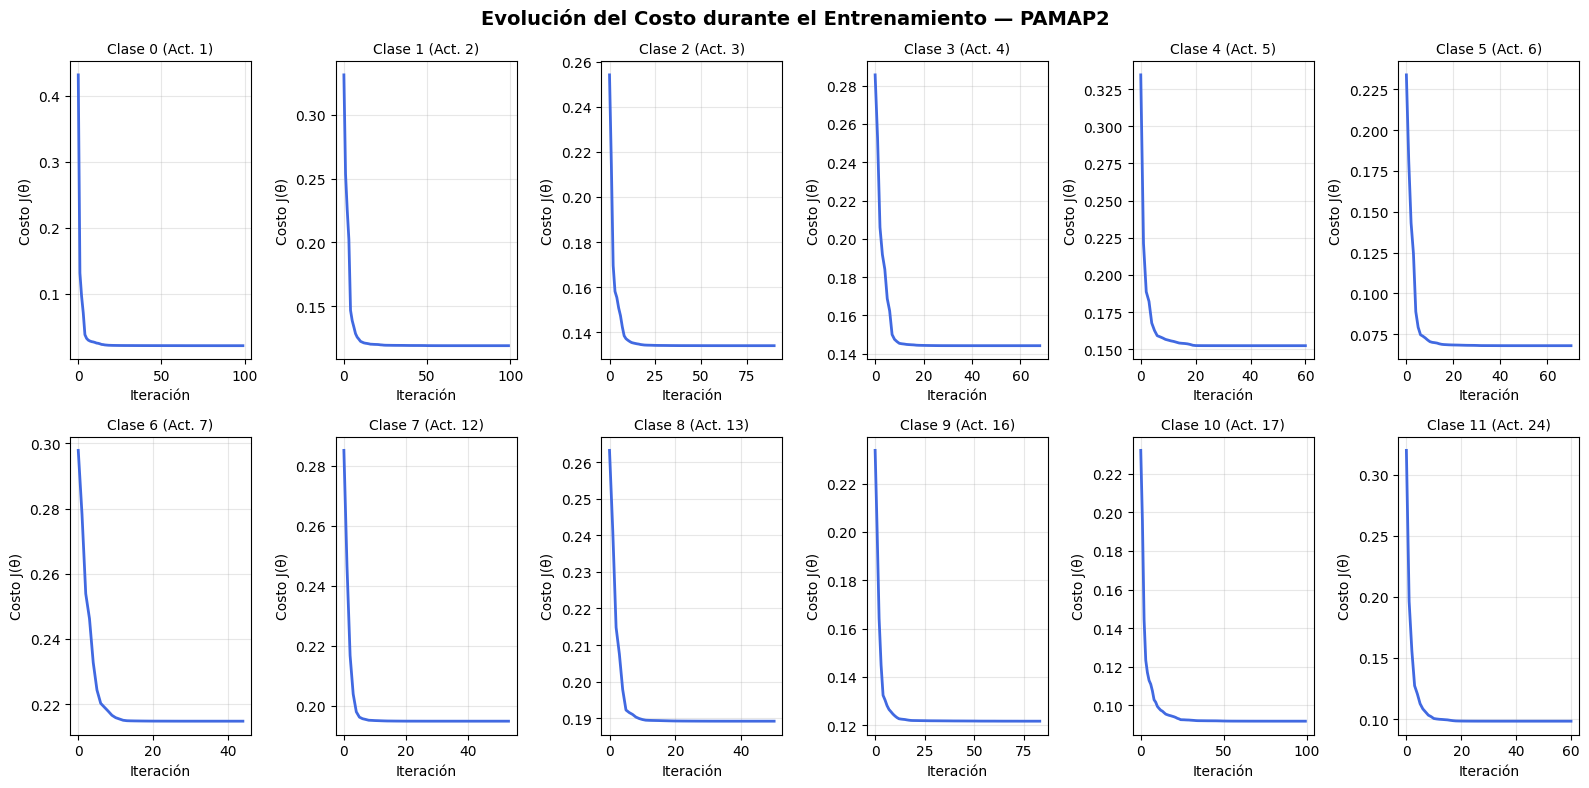

In [15]:
fig, axes = plt.subplots(2, (num_labels + 1) // 2, figsize=(16, 8))
axes = axes.flatten()

for c in range(num_labels):
    if len(costos_por_clase[c]) > 0:
        axes[c].plot(costos_por_clase[c], color='royalblue', linewidth=2)
        axes[c].set_title(f'Clase {c} (Act. {clases_unicas[c]})', fontsize=10)
        axes[c].set_xlabel('Iteración')
        axes[c].set_ylabel('Costo J(θ)')
        axes[c].grid(True, alpha=0.3)

# Ocultar ejes vacíos
for j in range(num_labels, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Evolución del Costo durante el Entrenamiento — PAMAP2', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Predicción y Validación del Modelo

El clasificador one-vs-all predice la clase $k^*$ como aquella cuyo clasificador logístico devuelve la mayor probabilidad:

$$\hat{y} = \arg\max_k \; g(\theta^{(k)T} x)$$

In [16]:
def predictOneVsAll(all_theta, X):
    m = X.shape[0]
    X_b = np.concatenate([np.ones((m, 1)), X], axis=1)
    p = np.argmax(sigmoid(X_b.dot(all_theta.T)), axis=1)
    return p

# Precisión en entrenamiento
pred_train = predictOneVsAll(all_theta, X_train_norm)
acc_train = np.mean(pred_train == y_train) * 100
print(f'Precisión en ENTRENAMIENTO: {acc_train:.2f}%')

# Precisión en prueba
pred_test = predictOneVsAll(all_theta, X_test_norm)
acc_test = np.mean(pred_test == y_test) * 100
print(f'Precisión en PRUEBA:        {acc_test:.2f}%')

Precisión en ENTRENAMIENTO: 74.15%
Precisión en PRUEBA:        73.53%


## 9. Gráficas de Precisión

Se visualiza la precisión por clase tanto en el conjunto de entrenamiento como en el de prueba. Esto permite identificar si alguna clase tiene bajo desempeño.

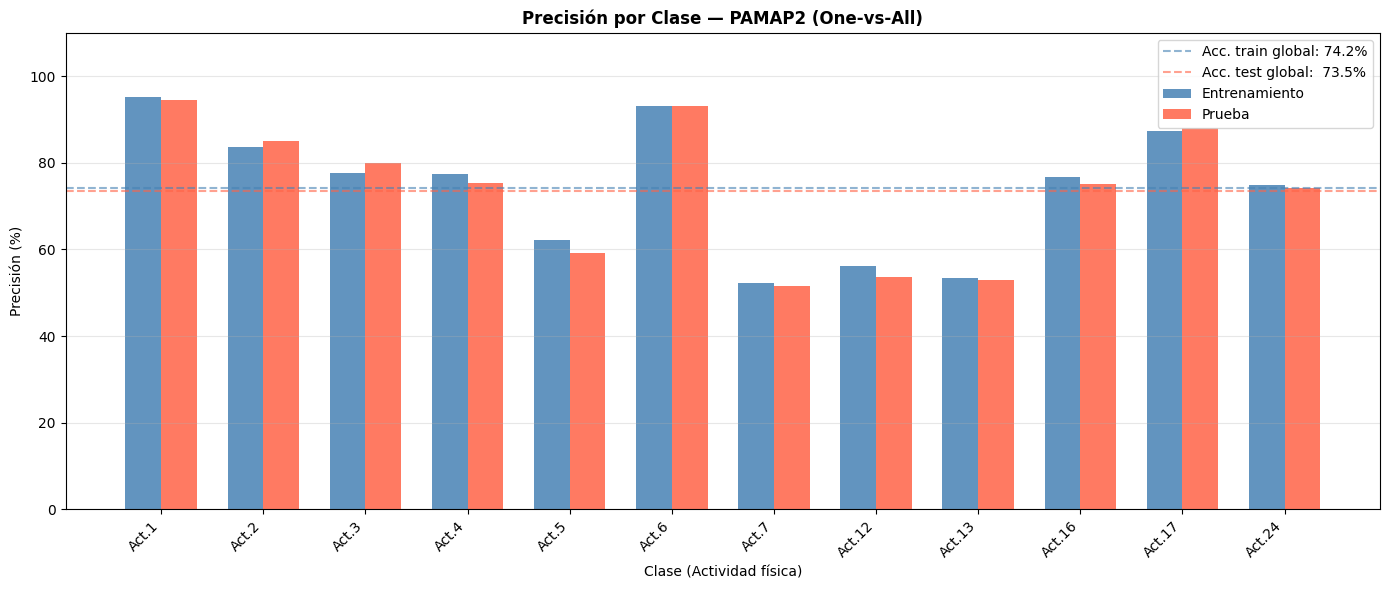

In [17]:
# Precisión por clase
acc_train_clase = []
acc_test_clase  = []

for c in range(num_labels):
    mask_train = (y_train == c)
    mask_test  = (y_test  == c)
    acc_train_clase.append(np.mean(pred_train[mask_train] == y_train[mask_train]) * 100)
    acc_test_clase.append( np.mean(pred_test[mask_test]   == y_test[mask_test])   * 100)

etiquetas_clases = [f'Act.{clases_unicas[c]}' for c in range(num_labels)]
x_pos = np.arange(num_labels)
ancho = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
barras1 = ax.bar(x_pos - ancho/2, acc_train_clase, ancho, label='Entrenamiento', color='steelblue', alpha=0.85)
barras2 = ax.bar(x_pos + ancho/2, acc_test_clase,  ancho, label='Prueba',        color='tomato',    alpha=0.85)

ax.axhline(y=acc_train, color='steelblue', linestyle='--', alpha=0.6, label=f'Acc. train global: {acc_train:.1f}%')
ax.axhline(y=acc_test,  color='tomato',    linestyle='--', alpha=0.6, label=f'Acc. test global:  {acc_test:.1f}%')

ax.set_xlabel('Clase (Actividad física)')
ax.set_ylabel('Precisión (%)')
ax.set_title('Precisión por Clase — PAMAP2 (One-vs-All)', fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(etiquetas_clases, rotation=45, ha='right')
ax.set_ylim(0, 110)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

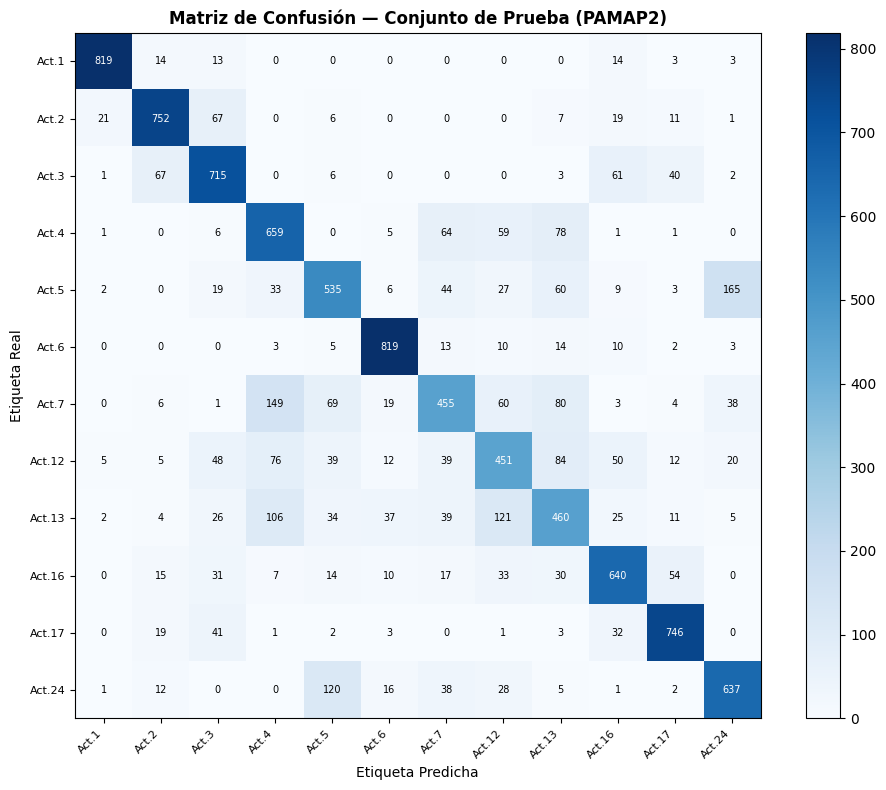

In [18]:
# Matriz de confusión en el conjunto de prueba
K = num_labels
conf_matrix = np.zeros((K, K), dtype=int)
for verdadero, predicho in zip(y_test, pred_test):
    conf_matrix[verdadero][predicho] += 1

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im)

tick_marks = np.arange(K)
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels([f'Act.{clases_unicas[c]}' for c in range(K)], rotation=45, ha='right', fontsize=8)
ax.set_yticklabels([f'Act.{clases_unicas[c]}' for c in range(K)], fontsize=8)

# Anotar valores
thresh = conf_matrix.max() / 2
for i in range(K):
    for j in range(K):
        ax.text(j, i, str(conf_matrix[i, j]),
                ha='center', va='center', fontsize=7,
                color='white' if conf_matrix[i, j] > thresh else 'black')

ax.set_ylabel('Etiqueta Real')
ax.set_xlabel('Etiqueta Predicha')
ax.set_title('Matriz de Confusión — Conjunto de Prueba (PAMAP2)', fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Resumen de Resultados

| Métrica | Valor |
|---|---|
| Ejemplos de entrenamiento | 80% del total |
| Ejemplos de prueba | 20% del total |
| Número de propiedades (n) | ≥ 40 |
| Número de clases | 12 actividades |
| λ (regularización) | 0.1 |
| Precisión en Entrenamiento | ver celda anterior |
| Precisión en Prueba | ver celda anterior |

El modelo de regresión logística one-vs-all fue capaz de clasificar correctamente la actividad física con alta precisión, demostrando la efectividad del enfoque vectorizado sobre datos de sensores inerciales del dataset PAMAP2.